In [1]:
import kagglehub
import os
import pandas as pd

# Download latest version
path = kagglehub.dataset_download("adharshinikumar/screentime-vs-mentalwellness-survey-2025")
path_data = os.path.join(path, "ScreenTime vs MentalWellness.csv")
data = pd.read_csv(path_data)

In [2]:
data.head()

,user_id,age,gender,occupation,work_mode,screen_time_hours,work_screen_hours,leisure_screen_hours,sleep_hours,sleep_quality_1_5,stress_level_0_10,productivity_0_100,exercise_minutes_per_week,social_hours_per_week,mental_wellness_index_0_100,Unnamed: 15
0,U0001,33,Female,Employed,Remote,10.79,5.44,5.35,6.63,1,9.3,44.7,127,0.7,9.3,NaN
1,U0002,28,Female,Employed,In-person,7.40,0.37,7.03,8.05,3,5.7,78.0,74,2.1,56.2,NaN
2,U0003,35,Female,Employed,Hybrid,9.78,1.09,8.69,6.48,1,9.1,51.8,67,8.0,3.6,NaN
3,U0004,42,Male,Employed,Hybrid,11.13,0.56,10.57,6.89,1,10.0,37.0,0,5.7,0.0,NaN
4,U0005,28,Male,Student,Remote,13.22,4.09,9.13,5.79,1,10.0,38.5,143,10.1,0.0,NaN


In [3]:
data.isnull().sum()

user_id                          0
age                              0
gender                           0
occupation                       0
work_mode                        0
screen_time_hours                0
work_screen_hours                0
leisure_screen_hours             0
sleep_hours                      0
sleep_quality_1_5                0
stress_level_0_10                0
productivity_0_100               0
exercise_minutes_per_week        0
social_hours_per_week            0
mental_wellness_index_0_100      0
Unnamed: 15                    400
dtype: int64

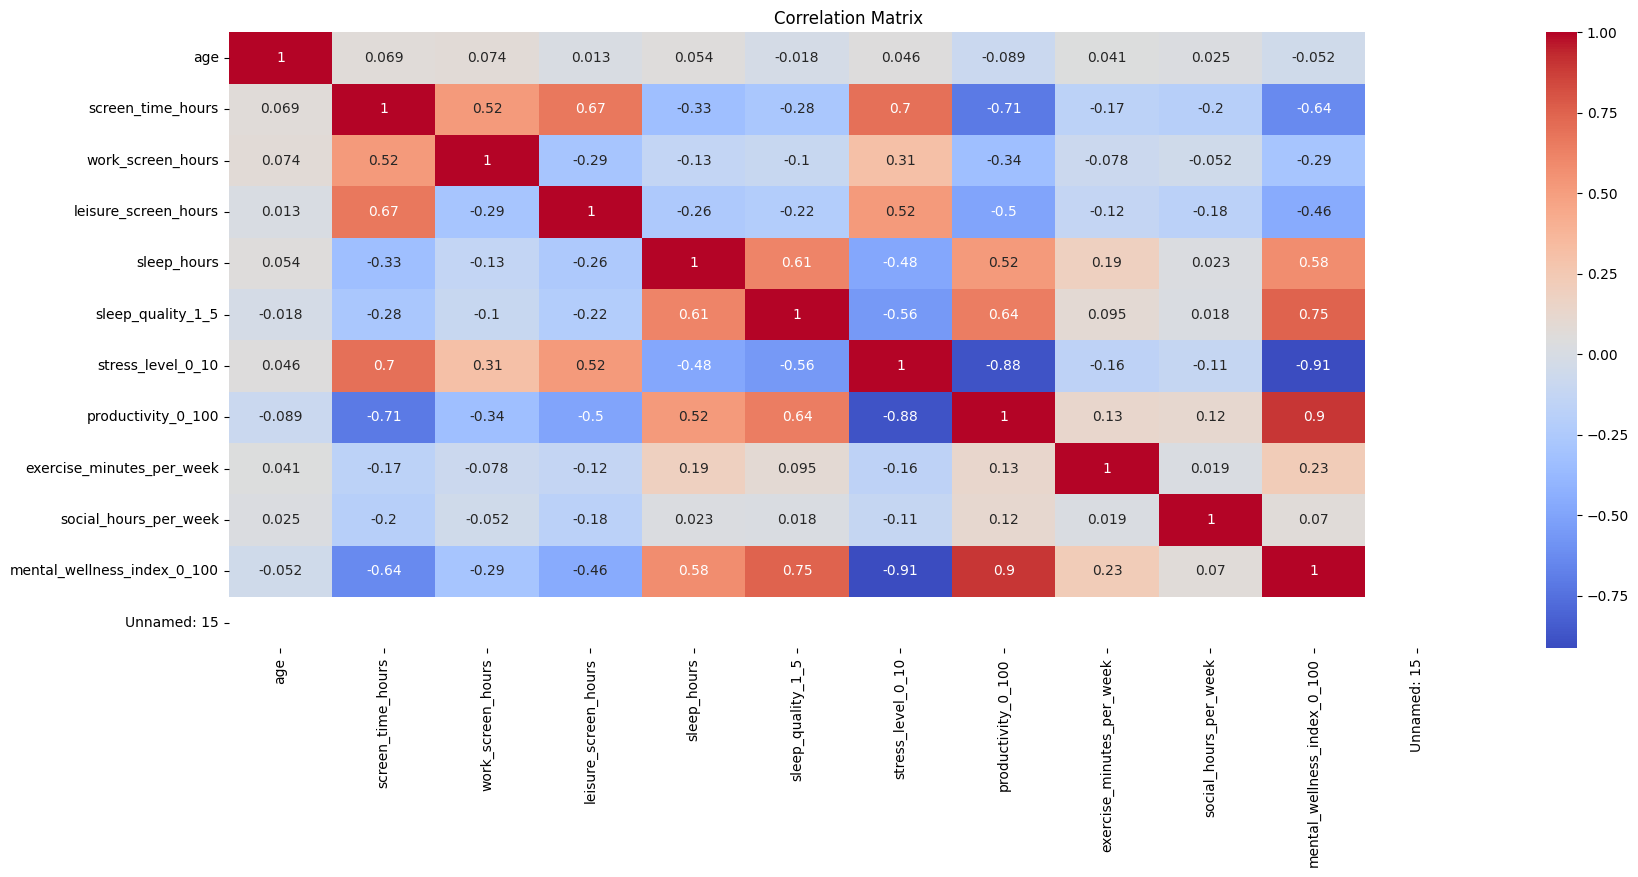

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20, 8))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

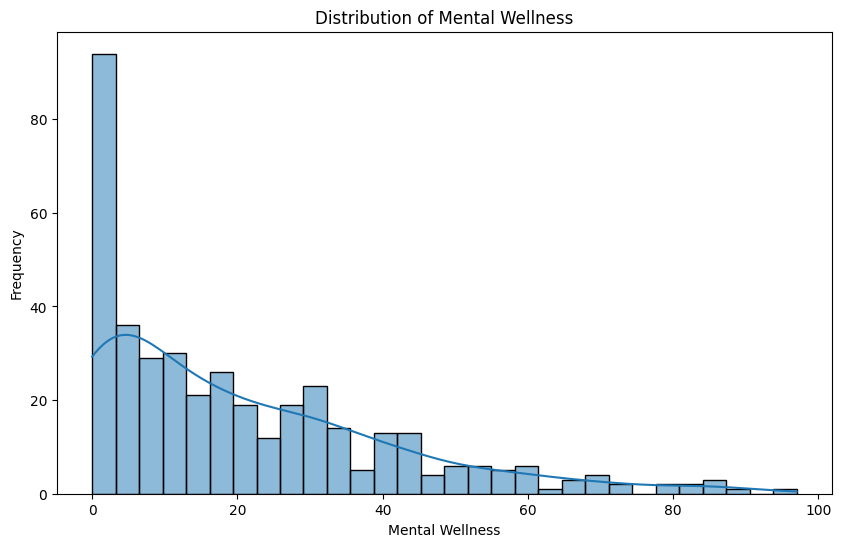

In [5]:
plt.figure(figsize=(10, 6))
sns.histplot(data['mental_wellness_index_0_100'], kde=True, bins=30)
plt.title('Distribution of Mental Wellness')
plt.xlabel('Mental Wellness')
plt.ylabel('Frequency')
plt.show()

In [6]:
data = data.drop(columns=["user_id", "Unnamed: 15"])

In [7]:
data.columns

Index(['age', 'gender', 'occupation', 'work_mode', 'screen_time_hours',
       'work_screen_hours', 'leisure_screen_hours', 'sleep_hours',
       'sleep_quality_1_5', 'stress_level_0_10', 'productivity_0_100',
       'exercise_minutes_per_week', 'social_hours_per_week',
       'mental_wellness_index_0_100'],
      dtype='object')

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          400 non-null    int64  
 1   gender                       400 non-null    object 
 2   occupation                   400 non-null    object 
 3   work_mode                    400 non-null    object 
 4   screen_time_hours            400 non-null    float64
 5   work_screen_hours            400 non-null    float64
 6   leisure_screen_hours         400 non-null    float64
 7   sleep_hours                  400 non-null    float64
 8   sleep_quality_1_5            400 non-null    int64  
 9   stress_level_0_10            400 non-null    float64
 10  productivity_0_100           400 non-null    float64
 11  exercise_minutes_per_week    400 non-null    int64  
 12  social_hours_per_week        400 non-null    float64
 13  mental_wellness_inde

In [9]:
data['gender'] = data['gender'].map({'Male': 1, 'Female': 2, 'Non-binary/Other': 3})
data['occupation'] = data['occupation'].map({'Employed': 1, 'Student': 2, 'Self-employed': 3, 'Retired': 4, 'Unemployed': 5})
data['work_mode'] = data['work_mode'].map({'Remote': 1, 'Hybrid': 2, 'In-person': 3})

In [10]:
data = data.query("mental_wellness_index_0_100 >= 2")
data

,age,gender,occupation,work_mode,screen_time_hours,work_screen_hours,leisure_screen_hours,sleep_hours,sleep_quality_1_5,stress_level_0_10,productivity_0_100,exercise_minutes_per_week,social_hours_per_week,mental_wellness_index_0_100
0,33,2,1,1,10.79,5.44,5.35,6.63,1,9.3,44.7,127,0.7,9.3
1,28,2,1,3,7.40,0.37,7.03,8.05,3,5.7,78.0,74,2.1,56.2
2,35,2,1,2,9.78,1.09,8.69,6.48,1,9.1,51.8,67,8.0,3.6
5,28,3,3,2,9.83,0.53,9.30,7.19,1,10.0,44.0,71,10.3,5.0
6,42,3,4,1,6.02,2.82,3.20,7.44,2,6.1,64.8,141,4.7,43.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,26,2,2,1,6.43,2.99,3.44,7.75,1,5.9,64.6,252,7.6,39.3
396,16,1,3,1,9.59,5.44,4.15,5.57,1,10.0,47.4,99,7.0,3.5
397,40,1,2,1,8.72,2.36,6.36,7.56,1,9.4,57.3,193,10.1,6.6
398,29,2,4,2,5.04,0.94,4.10,7.32,1,7.1,63.6,97,12.1,21.0


In [11]:
from sklearn.model_selection import train_test_split

selected_data = data[["screen_time_hours", "sleep_quality_1_5", "stress_level_0_10", "sleep_hours", "age"]]

# X = data.drop(columns=["mental_wellness_index_0_100"])
y = data["mental_wellness_index_0_100"]
X_train, X_test, y_train, y_test = train_test_split(selected_data, y, test_size=0.2, random_state=42)

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
import xgboost as xgb
from sklearn.metrics import r2_score, mean_absolute_percentage_error, mean_squared_error, mean_absolute_error

In [13]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "Support Vector Regressor": SVR(),
    "XGBoost": xgb.XGBRegressor(random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        "Model": name,
        "MAPE": mape,
        "R2 Score": r2
    })


results_df = pd.DataFrame(results)
print(results_df.sort_values(by="MAPE"))

                      Model      MAPE  R2 Score
0         Linear Regression  0.322154  0.898320
2         Gradient Boosting  0.360918  0.858022
4                   XGBoost  0.397683  0.811570
1             Random Forest  0.418127  0.860207
3  Support Vector Regressor  0.913574  0.226749


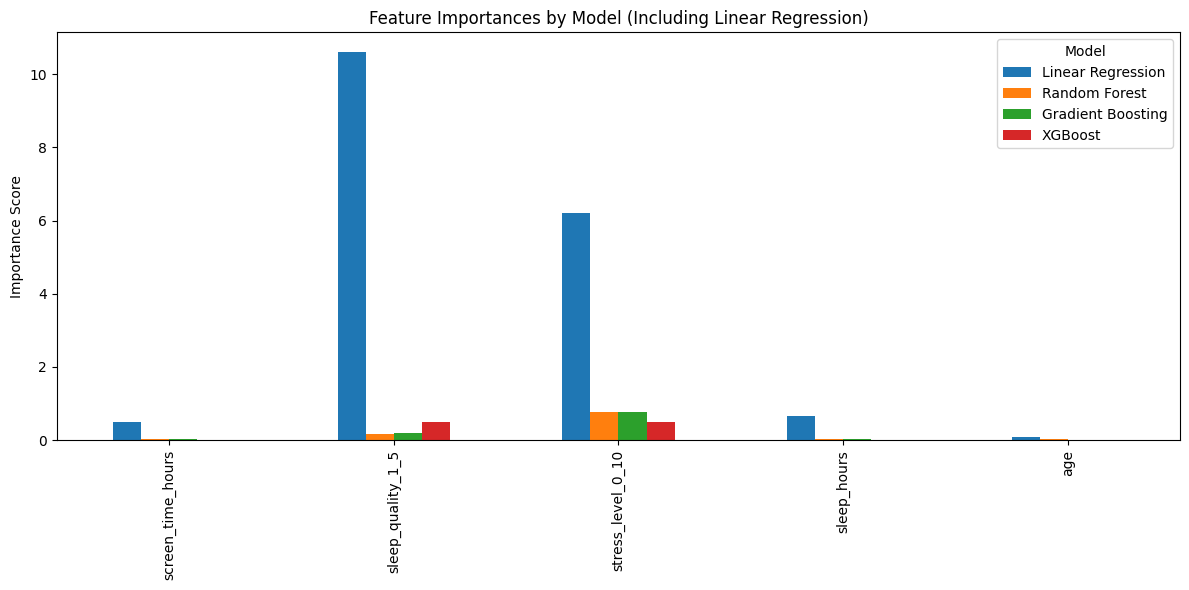

In [14]:
import numpy as np

feature_importances = {}

for name, model in models.items():
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
        feature_importances[name] = importances
    elif hasattr(model, "coef_"):
        importances = np.abs(model.coef_)
        feature_importances[name] = importances

importance_df = pd.DataFrame(feature_importances, index=X_train.columns)

ax = importance_df.plot(kind='bar', figsize=(12, 6))
plt.title("Feature Importances by Model (Including Linear Regression)")
plt.ylabel("Importance Score")
plt.legend(title="Model")
plt.tight_layout()
plt.show()

In [15]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mape = mean_absolute_percentage_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [16]:
field = pd.DataFrame([{
    "screen_time_hours" : 0,
    "sleep_quality_1_5" : 5,
    "stress_level_0_10" : 0,
    "sleep_hours" : 12,
    "age" : 12
}])


pred = model.predict(field)[0]
print(pred)

119.0494467734242


In [17]:
import pandas as pd
import numpy as np

# สร้าง DataFrame เปรียบเทียบ
comparison_df = pd.DataFrame({
    'y_test': y_test,
    'y_pred': y_pred,
    'abs_error': np.abs(y_test - y_pred),
    'pct_error': np.abs((y_test - y_pred) / y_test) * 100
})

# แสดงผลลัพธ์บางส่วน
print(comparison_df.head())

     y_test     y_pred  abs_error  pct_error
93     14.4  14.642547   0.242547   1.684357
280    12.8   5.553114   7.246886  56.616300
35     14.8  17.302695   2.502695  16.910100
268    16.1   8.872446   7.227554  44.891641
11     74.3  63.162361  11.137639  14.990093


In [18]:
print(mape)
print(r2)

0.32215358764194435
0.8983203687036265


In [ ]:
import joblib

best_result = min(results, key=lambda x: x["MAPE"])
best_model_name = best_result["Model"]
best_model = models[best_model_name]

joblib.dump(best_model, f"{best_model_name}_best_model.pkl")
joblib.dump(X_train.columns.tolist(), "feature_names.pkl")
print(f"Saved best model: {best_model_name}")